<a href="https://colab.research.google.com/github/shalini2006official/Hierarchical-clustering/blob/main/Housing_using_hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/housing.csv")

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
from scipy.stats import zscore
numeric_col=df.select_dtypes(include=np.number)
z_scores=np.abs(zscore(numeric_col))
outlier=df[(z_scores>2.5).any (axis=1)]
print(outlier)

        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
89      1.2434      52.0  2.929412   0.917647       396.0  4.658824     37.80   
131    11.6017      18.0  8.335052   1.082474       533.0  2.747423     37.84   
155     8.8793      52.0  8.972868   1.131783       861.0  3.337209     37.81   
185     2.1917      43.0  4.844029   1.091795      4367.0  3.547522     37.79   
283     5.9849      22.0  6.528724   1.041179      4985.0  2.534316     37.79   
...        ...       ...       ...        ...         ...       ...       ...   
20529   2.9605      12.0  4.915341   1.022451      5633.0  2.634705     38.55   
20530   3.1371      11.0  5.070223   1.015530      7984.0  2.695476     38.57   
20544   2.0650      23.0  4.803493   1.013646      6330.0  3.455240     38.55   
20563   3.1250       9.0  5.148007   1.119593      6837.0  2.899491     38.67   
20629   2.0943      28.0  5.519802   1.020902      6912.0  3.801980     39.12   

       Longitude  MedHouseV

In [ ]:
from scipy.stats.mstats import winsorize
cols = df.select_dtypes(include=np.number)
for col in cols:
  df[col]=winsorize(df[col],limits=[0,0.1])
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      6.1592      41.0  6.961165   1.023810       322.0  2.555556     37.88   
1      6.1592      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      6.1592      46.0  6.961165   1.073446       496.0  2.802260     37.85   
3      5.6431      46.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      46.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     38.48   
20636  2.5568      18.0  6.114035   1.172727       356.0  3.122807     38.48   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     38.48   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     38.48   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     38.48   

       Longitude  MedHouseVal  
0      

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering


In [ ]:
q = df.iloc[:, 3:].values

In [ ]:
# X = df.drop("MedHouseVal", axis=1)

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
linked = linkage(q, method='ward')

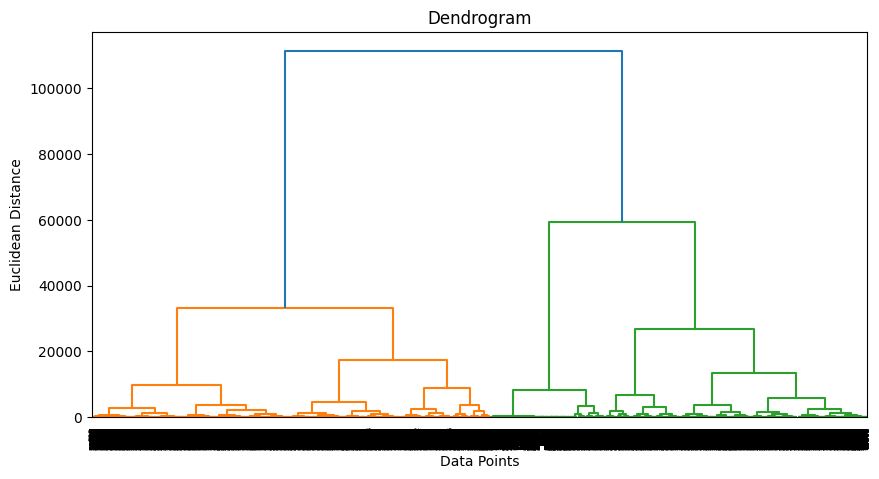

In [ ]:
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
model = hc.fit(q)

In [ ]:
label = model.labels_

print(label)


[0 2 0 ... 0 0 1]
